# Advanced iSLAT Plotting API

This notebook goes deeper into the iSLAT plotting module, demonstrating
techniques that go beyond the basics covered in `Plotting_Examples.ipynb`.

## What This Notebook Covers

1. **BasePlot Rendering Helpers** -- Using the low-level `_plot_*` methods to build fully custom figures
2. **Atomic & Saved Line Annotations** -- Overlaying catalogue markers on any plot
3. **Molecule Visibility Control** -- Toggling molecules on/off and observing the effect on plots
4. **FullSpectrumPlot Deep Dive** -- Panel layout, line-list annotations, in-place updates, and PDF export
5. **MainPlotGrid Interactive Updates** -- Changing molecule, inspection range, and line data on the fly
6. **Multi-Spectrum Comparison** -- Overlaying different datasets on a shared axes layout
7. **Custom Figure Composition** -- Mixing iSLAT plot classes with raw matplotlib in a single figure
8. **Theming All Plot Types** -- Applying a consistent dark theme across every plot class

In [1]:
# === Imports ===
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from IPython.display import display
from pathlib import Path

# iSLAT data types
from iSLAT.Modules.DataTypes import Molecule, MoleculeDict

# iSLAT plotting classes & theme
from iSLAT.Modules.Plotting import (
    BasePlot,
    DEFAULT_THEME,
    load_theme,
    LineInspectionPlot,
    PopulationDiagramPlot,
    FullSpectrumPlot,
    MainPlotGrid,
)

# File paths for example data & HITRAN line lists
from iSLAT.Modules.FileHandling import (
    example_data_folder_path,
    hitran_data_folder_path,
    atomic_lines_file_name,
)

print("Imports OK [OK]")

Imports OK [OK]


In [2]:
# === Load observed spectrum & build MoleculeDict ===

data_path = example_data_folder_path / "CITau_MIRI_Banzatti+2023b.csv"
obs = pd.read_csv(data_path)

wave_grid     = obs["wave"].values
observed_flux = obs["flux"].values
observed_err  = obs["err"].values

print(f"Loaded {data_path.name}: {len(wave_grid)} pts, {wave_grid.min():.2f}-{wave_grid.max():.2f} um")

# HITRAN parameter files
data_dir = hitran_data_folder_path
water_par = str(data_dir / "data_Hitran_H2O.par")
co_par    = str(data_dir / "data_Hitran_CO.par")
co2_par   = str(data_dir / "data_Hitran_CO2.par")

wavelength_range = (float(wave_grid.min()), float(wave_grid.max()))

mol_dict = MoleculeDict(
    global_distance=160,
    global_stellar_rv=0.0,
    global_wavelength_range=wavelength_range,
    global_model_pixel_res=0.0013,
)

molecules_to_create = {
    "H2O": {"Molecule Name": "H2O", "temp": 850, "n_mol": 1e18, "radius": 0.5,
             "color": "#0000FF", "displaylabel": "$H_2O$", "File Path": water_par},
    "CO":  {"Molecule Name": "CO",  "temp": 1000, "n_mol": 1e18, "radius": 0.4,
             "color": "#FF0000", "displaylabel": "CO",    "File Path": co_par},
    "CO2": {"Molecule Name": "CO2", "temp": 300,  "n_mol": 1e17, "radius": 0.5,
             "color": "green",   "displaylabel": "$CO_2$", "File Path": co2_par},
}

mol_dict.load_molecules(
    molecules_data=[v for v in molecules_to_create.values()],
    initial_molecule_parameters=molecules_to_create,
)
mol_dict.bulk_update_parameters({"fwhm": 130, "broad": 1})

print(f"MoleculeDict ready: {list(mol_dict.keys())}")

Loaded CITau_MIRI_Banzatti+2023b.csv: 10672 pts, 4.90-28.72 um
Deferring intensity calculations for 3 molecules
MoleculeDict ready: ['H2O', 'CO', 'CO2']


---
## 1. BasePlot Rendering Helpers

Every iSLAT plot class inherits a suite of `_plot_*` helpers from `BasePlot`.
You can call them directly on any `BasePlot` subclass to compose custom figures
piece by piece:

| Helper | What it draws |
|--------|---------------|
| `_plot_observed_spectrum(ax, wave, flux, err)` | Data line + optional error bars |
| `_plot_molecule_spectrum(ax, mol, wave)` | Single molecule model (dashed) |
| `_plot_visible_molecules(ax, mol_dict, wave)` | All visible molecules |
| `_plot_summed_spectrum(ax, wave, flux)` | Grey fill for the summed model |
| `_plot_line_annotations(ax, df, xr, ymin, ymax)` | Saved line vertical markers |
| `_plot_atomic_lines(ax, df)` | Atomic line markers (tomato) |
| `_plot_saved_line_markers(ax, df)` | Saved line markers with colour coding |
| `_update_legend(ax)` | Rebuild legend excluding hidden artists |

Because these are instance methods on `BasePlot`, we need a lightweight plot object
to call them through. A `LineInspectionPlot` is the simplest option.

Calculating intensity for H2O: T=850.0K, N_mol=1.00e+18, dv=1.0
Calculating intensity for CO2: T=300.0K, N_mol=1.00e+17, dv=1.0
Calculating intensity for CO2: T=300.0K, N_mol=1.00e+17, dv=1.0
Calculating intensity for CO: T=1000.0K, N_mol=1.00e+18, dv=1.0
Calculating intensity for CO: T=1000.0K, N_mol=1.00e+18, dv=1.0


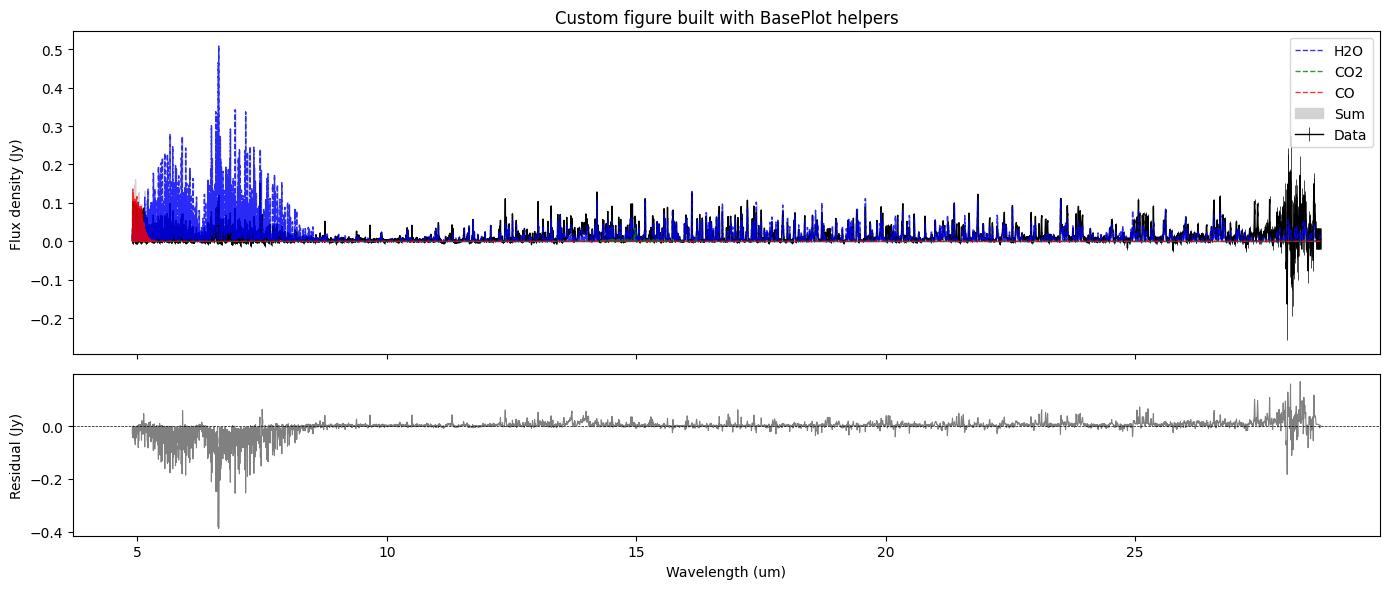

In [3]:
# --- Build a custom two-panel figure using BasePlot helpers ---

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                                      gridspec_kw={"height_ratios": [2, 1]})

# We need a BasePlot instance to access the rendering helpers.
# LineInspectionPlot is the lightest subclass to instantiate.
helper = LineInspectionPlot(
    wave_data=wave_grid, flux_data=observed_flux,
    xmin=wave_grid.min(), xmax=wave_grid.max(),
)

# -- Top: observed spectrum + all visible molecule models + summed fill --
helper._plot_observed_spectrum(ax_top, wave_grid, observed_flux, observed_err)
helper._plot_visible_molecules(ax_top, mol_dict, wave_data=wave_grid)

try:
    s_wave, s_flux = mol_dict.get_summed_flux(wave_grid, visible_only=True)
    helper._plot_summed_spectrum(ax_top, s_wave, s_flux)
except Exception:
    pass

ax_top.set_ylabel("Flux density (Jy)")
ax_top.set_title("Custom figure built with BasePlot helpers")
BasePlot._update_legend(ax_top)

# -- Bottom: residual (data - summed model) --
if s_flux is not None:
    # Interpolate summed model onto the observed grid
    residual = observed_flux - np.interp(wave_grid, s_wave, s_flux)
    ax_bot.plot(wave_grid, residual, color="gray", linewidth=0.8)
    ax_bot.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax_bot.set_xlabel("Wavelength (um)")
ax_bot.set_ylabel("Residual (Jy)")

fig.tight_layout()
plt.show()

---
## 2. Atomic & Saved Line Annotations

The `BasePlot._plot_atomic_lines()` and `_plot_line_annotations()` static methods
accept a DataFrame and draw vertical markers on any axes. You can load the bundled
atomic-lines catalogue or create your own annotation DataFrame.

In [4]:
# Load the bundled atomic-line catalogue
import iSLAT.Modules.FileHandling.iSLATFileHandling as ifh

atomic_df = ifh.load_atomic_lines()
print(f"Atomic lines loaded: {len(atomic_df)} entries")
atomic_df.head()

Atomic lines loaded: 54 entries


,wave,species,line
0,4.052281,HI,(5-4)
1,7.459882,HI,(6-5)
2,4.653792,HI,(7-5)
3,3.740567,HI,(8-5)
4,3.297001,HI,(9-5)


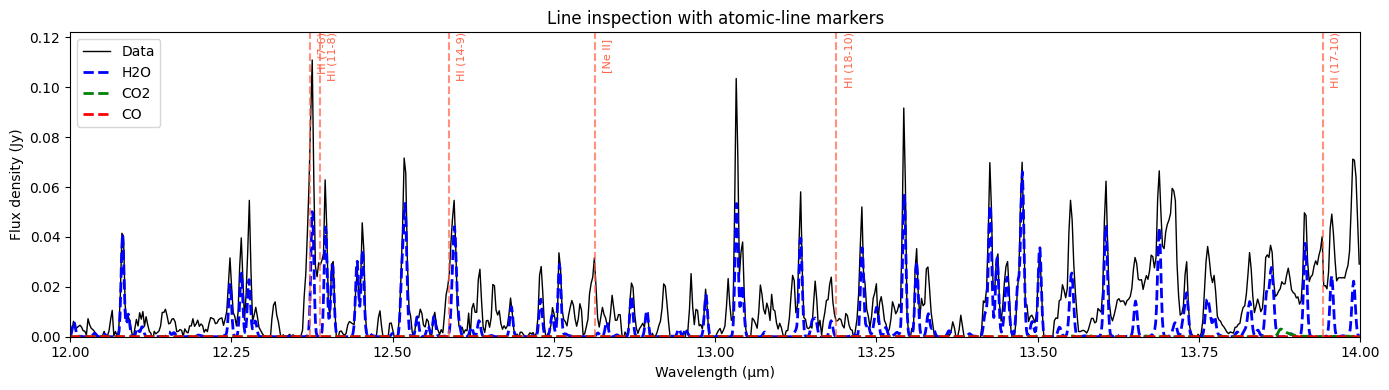

In [5]:
# --- Annotate a LineInspectionPlot with atomic lines ---

fig, ax = plt.subplots(figsize=(14, 4))

lip_annotated = LineInspectionPlot(
    wave_data=wave_grid, flux_data=observed_flux,
    xmin=12.0, xmax=14.0,
    molecules=mol_dict,
    ax=ax,
)
lip_annotated.generate_plot()

# Overlay atomic lines on top
BasePlot._plot_atomic_lines(ax, atomic_df, xr=(12.0, 14.0))

ax.set_title("Line inspection with atomic-line markers")
fig.tight_layout()
plt.show()

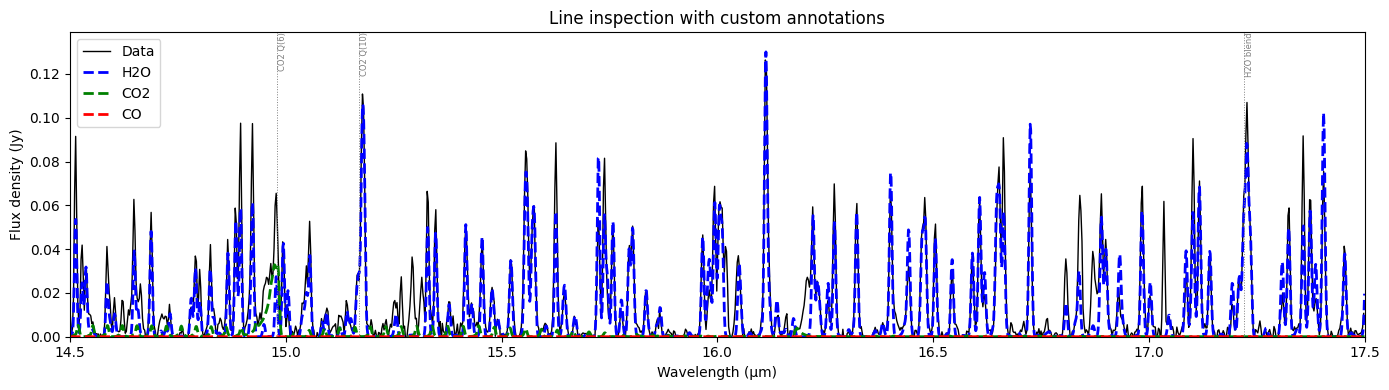

In [6]:
# --- Custom annotation DataFrame ---
# You can create your own line-list DataFrame with 'wave', 'species', 'line' columns

custom_lines = pd.DataFrame({
    "wave":    [14.98, 15.17, 17.22],
    "species": ["CO2", "CO2", "H2O"],
    "line":    ["Q(6)", "Q(10)", "blend"],
})

fig, ax = plt.subplots(figsize=(14, 4))

lip_custom = LineInspectionPlot(
    wave_data=wave_grid, flux_data=observed_flux,
    xmin=14.5, xmax=17.5,
    molecules=mol_dict,
    ax=ax,
)
lip_custom.generate_plot()

# Draw custom annotations
ymin, ymax = ax.get_ylim()
BasePlot._plot_line_annotations(ax, custom_lines, xr=(14.5, 17.5), ymin=ymin, ymax=ymax)

ax.set_title("Line inspection with custom annotations")
fig.tight_layout()
plt.show()

---
## 3. Molecule Visibility Control

Each `Molecule` has an `is_visible` property. Toggling it controls which molecules
appear in any plot that uses `MoleculeDict.get_visible_molecules()` (which all the
`_plot_visible_molecules` and `get_summed_flux` calls rely on).

  H2O    visible=True
  CO     visible=True
  CO2    visible=True


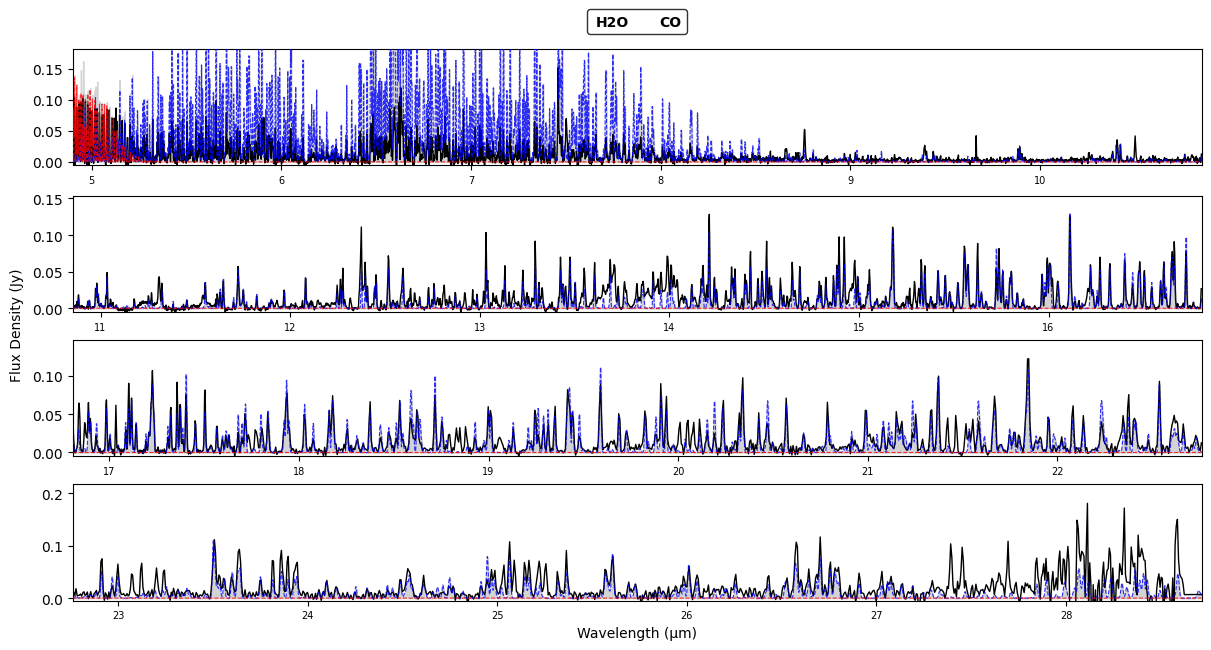


(CO2 visibility restored)


In [7]:
# Show current visibility state
for name, mol in mol_dict.items():
    print(f"  {name:5s}  visible={mol.is_visible}")

# Hide CO2 and regenerate a FullSpectrumPlot
mol_dict["CO2"].is_visible = False

fsp_vis = FullSpectrumPlot(
    wave_data=wave_grid, flux_data=observed_flux,
    molecules=mol_dict, n_panels=4,
)
fsp_vis.generate_plot()
fsp_vis.show()

# Restore for later examples
mol_dict["CO2"].is_visible = True
print("\n(CO2 visibility restored)")

---
## 4. FullSpectrumPlot Deep Dive

### 4a. Panel layout control

`FullSpectrumPlot` divides the wavelength range into panels. You can control this via:
- `n_panels` -- target number of panels (step is computed automatically)
- `step` -- fixed wavelength width per panel (overrides `n_panels`)
- `xlim_range` -- restrict to a sub-range of the data

### 4b. Line-list and atomic-line annotations

Pass `line_list` and/or `atomic_lines` DataFrames to the constructor and they will be
rendered on every panel automatically.

### 4c. In-place data update via `update_data()` + `update_panels_inplace()`

When the panel layout hasn't changed, you can update data without rebuilding the
entire figure -- this is much faster than calling `generate_plot()` again.

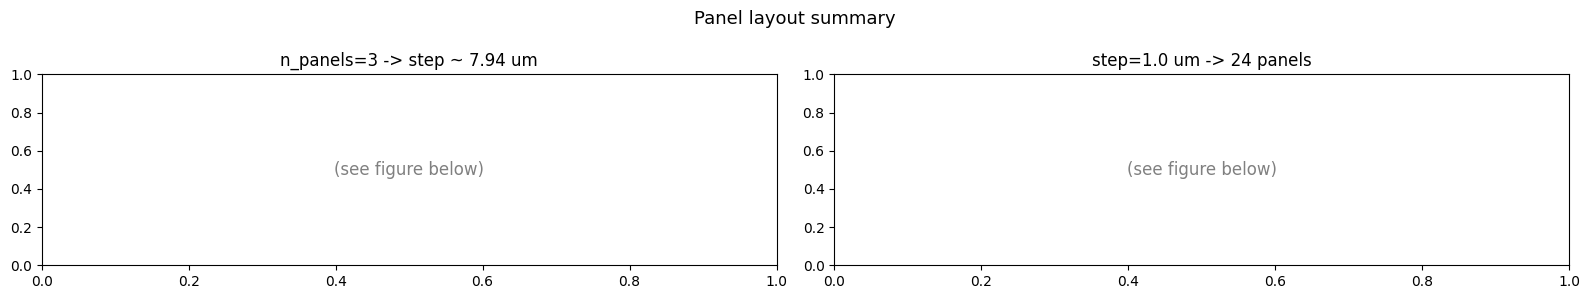


-- 3-panel layout --


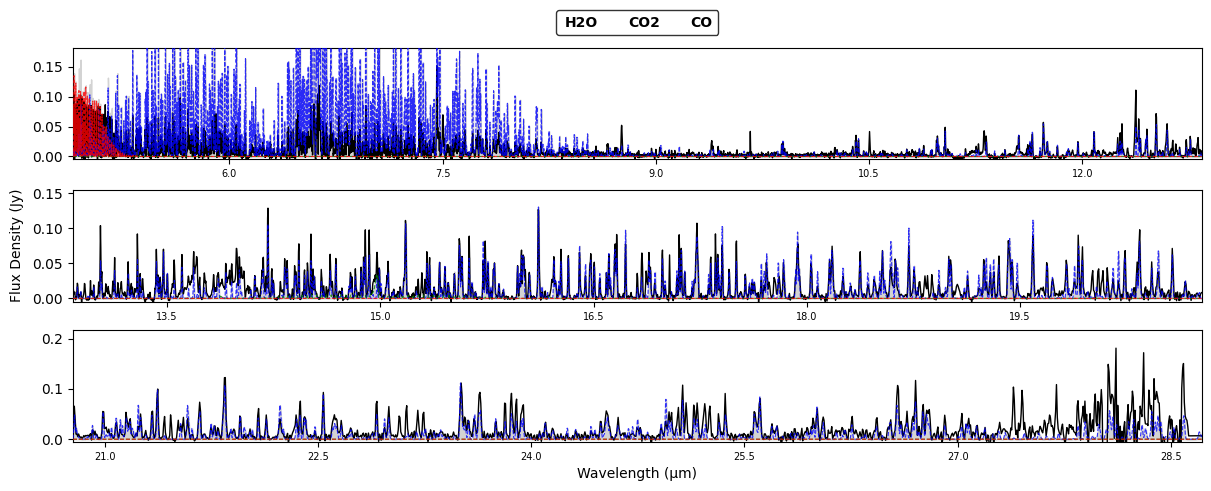


-- 1 um step layout --


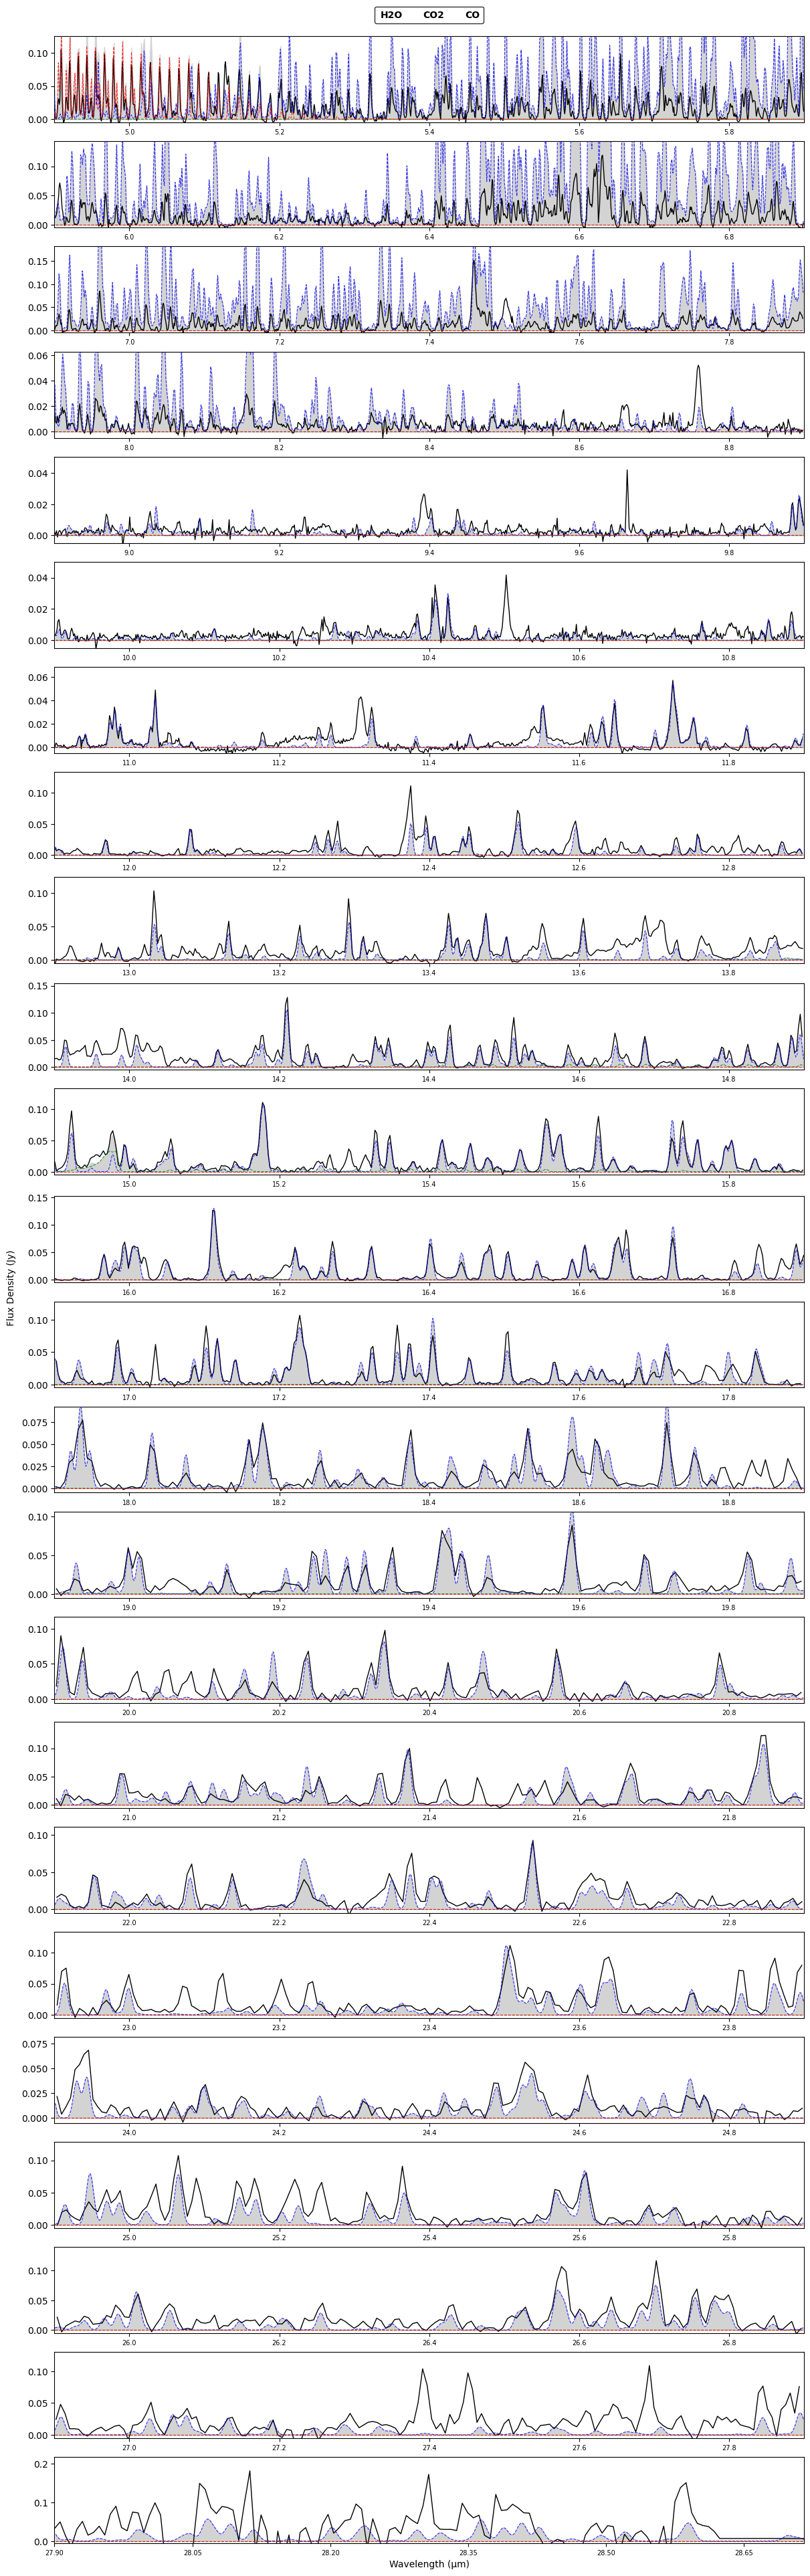

In [8]:
# --- 4a: Panel layout comparison ---

fig, axes = plt.subplots(1, 2, figsize=(16, 3))

# Left: 3 panels (default step)
fsp3 = FullSpectrumPlot(
    wave_data=wave_grid, flux_data=observed_flux,
    molecules=mol_dict, n_panels=3,
)
fsp3.generate_plot()
axes[0].set_title(f"n_panels=3 -> step ~ {fsp3._step:.2f} um")
axes[0].text(0.5, 0.5, "(see figure below)", ha="center", va="center",
             transform=axes[0].transAxes, fontsize=12, color="gray")

# Right: fixed step of 1 um
fsp1um = FullSpectrumPlot(
    wave_data=wave_grid, flux_data=observed_flux,
    molecules=mol_dict, step=1.0,
)
fsp1um.generate_plot()
n_actual = len(fsp1um._panel_edges)
axes[1].set_title(f"step=1.0 um -> {n_actual} panels")
axes[1].text(0.5, 0.5, "(see figure below)", ha="center", va="center",
             transform=axes[1].transAxes, fontsize=12, color="gray")

fig.suptitle("Panel layout summary", fontsize=13)
fig.tight_layout()
plt.show()

# Show the actual generated figures
print("\n-- 3-panel layout --")
fsp3.show()
print("\n-- 1 um step layout --")
fsp1um.show()

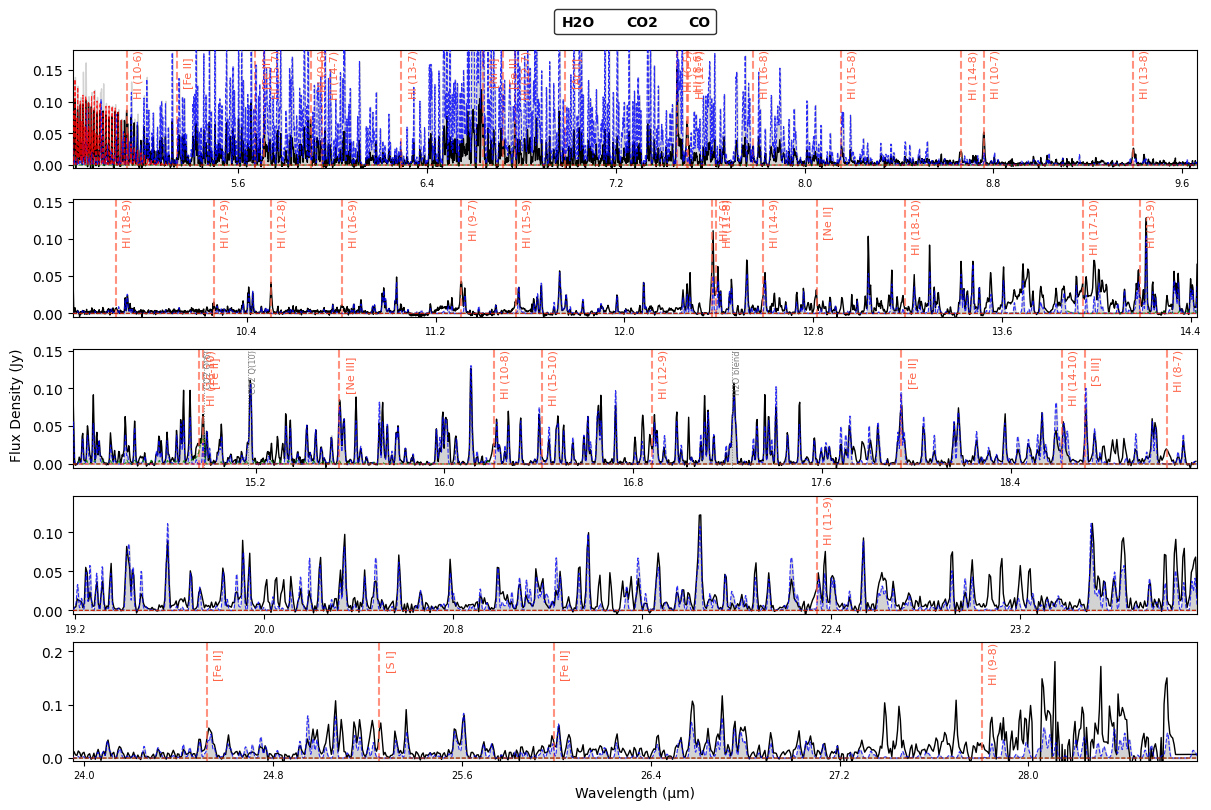

In [9]:
# --- 4b: Line annotations on FullSpectrumPlot ---

fsp_annotated = FullSpectrumPlot(
    wave_data=wave_grid,
    flux_data=observed_flux,
    molecules=mol_dict,
    n_panels=5,
    line_list=custom_lines,       # saved-line annotations
    atomic_lines=atomic_df,       # atomic-line annotations
)
fsp_annotated.generate_plot()
fsp_annotated.show()

Original plot:


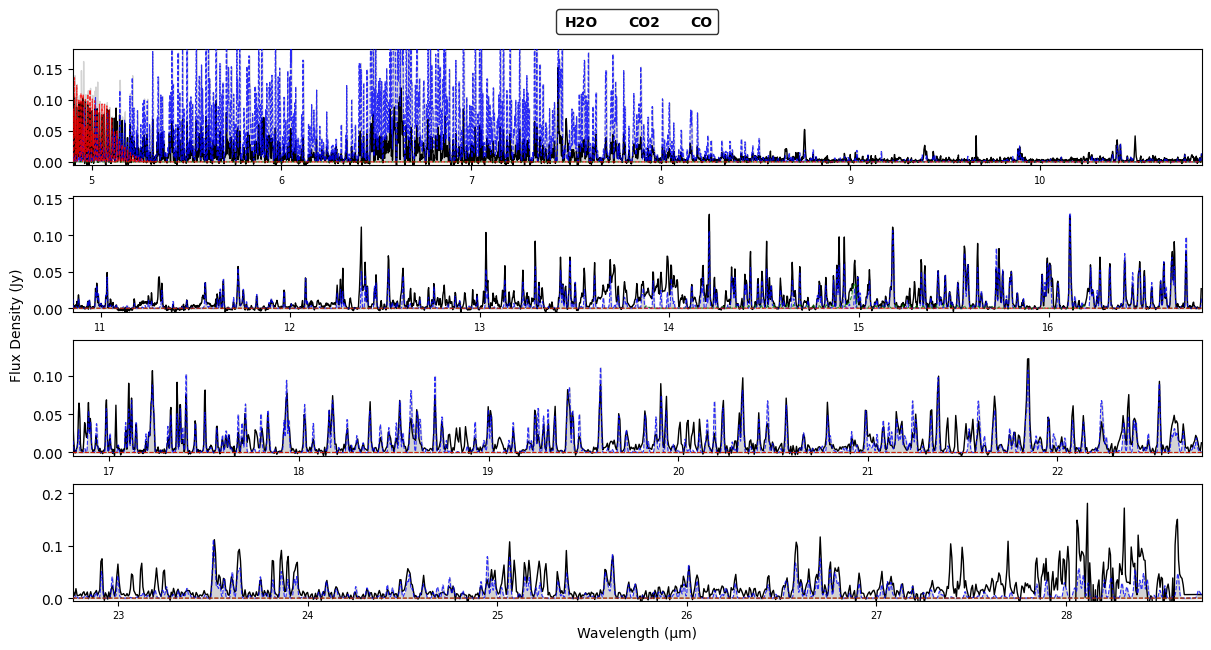


Layout changed? False
Calculating intensity for H2O: T=1200.0K, N_mol=1.00e+18, dv=1.0
Fast in-place update applied.
Fast in-place update applied.


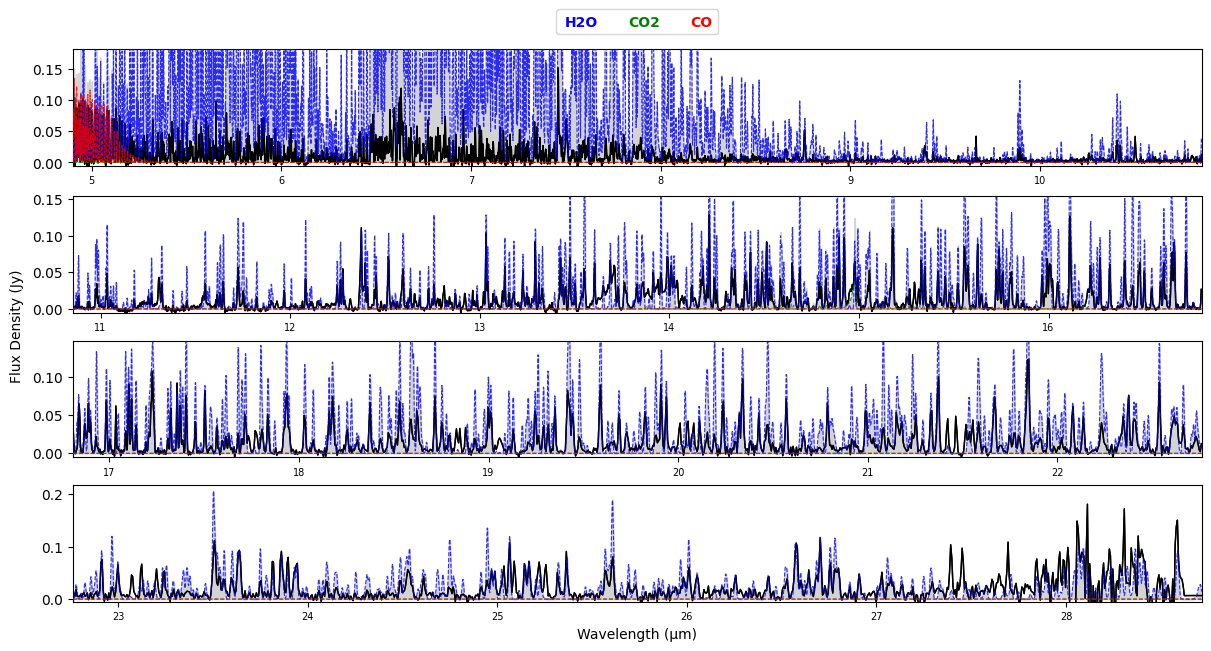

In [10]:
# --- 4c: In-place panel update ---
# Change a molecule parameter and update panels without rebuilding the figure.

fsp_inplace = FullSpectrumPlot(
    wave_data=wave_grid, flux_data=observed_flux,
    molecules=mol_dict, n_panels=4,
)
fsp_inplace.generate_plot()
print("Original plot:")
fsp_inplace.show()

# Now change H2O temperature and update in-place (no fig.clf())
mol_dict["H2O"].bulk_update_parameters({"temp": 1200})

layout_changed = fsp_inplace.update_data(
    wave_data=wave_grid,
    flux_data=observed_flux,
    molecules=mol_dict,
)
print(f"\nLayout changed? {layout_changed}")

if not layout_changed:
    fsp_inplace.update_panels_inplace()
    print("Fast in-place update applied.")
else:
    fsp_inplace.generate_plot()
    print("Full rebuild triggered.")

display(fsp_inplace.fig)

# Restore the original temperature
mol_dict["H2O"].bulk_update_parameters({"temp": 850})

In [11]:
# --- 4d: Saving a FullSpectrumPlot to PDF ---

fsp_save = FullSpectrumPlot(
    wave_data=wave_grid, flux_data=observed_flux,
    molecules=mol_dict, n_panels=6, figsize=(12, 14),
)
fsp_save.generate_plot()

out_path = Path.cwd() / "full_spectrum_demo.pdf"
saved = fsp_save.save(out_path, dpi=150)
print(f"Saved to output directory  ({saved.stat().st_size / 1024:.0f} KB)")
fsp_save.close()

Calculating intensity for H2O: T=850.0K, N_mol=1.00e+18, dv=1.0
Saved to output directory  (487 KB)
Saved to output directory  (487 KB)


---
## 5. MainPlotGrid Interactive Updates

`MainPlotGrid` mirrors the three-panel GUI layout. After the initial
`generate_plot()`, you can update individual panels without regenerating
the whole figure:

| Method | What it updates |
|--------|-----------------|
| `set_inspection_range(xmin, xmax)` | Bottom-left (line inspection) + bottom-right (pop diagram) |
| `set_active_molecule(mol)` | Bottom-left + bottom-right |
| `set_line_data(lines)` | Bottom-left line markers |
| `refresh()` | All three panels |

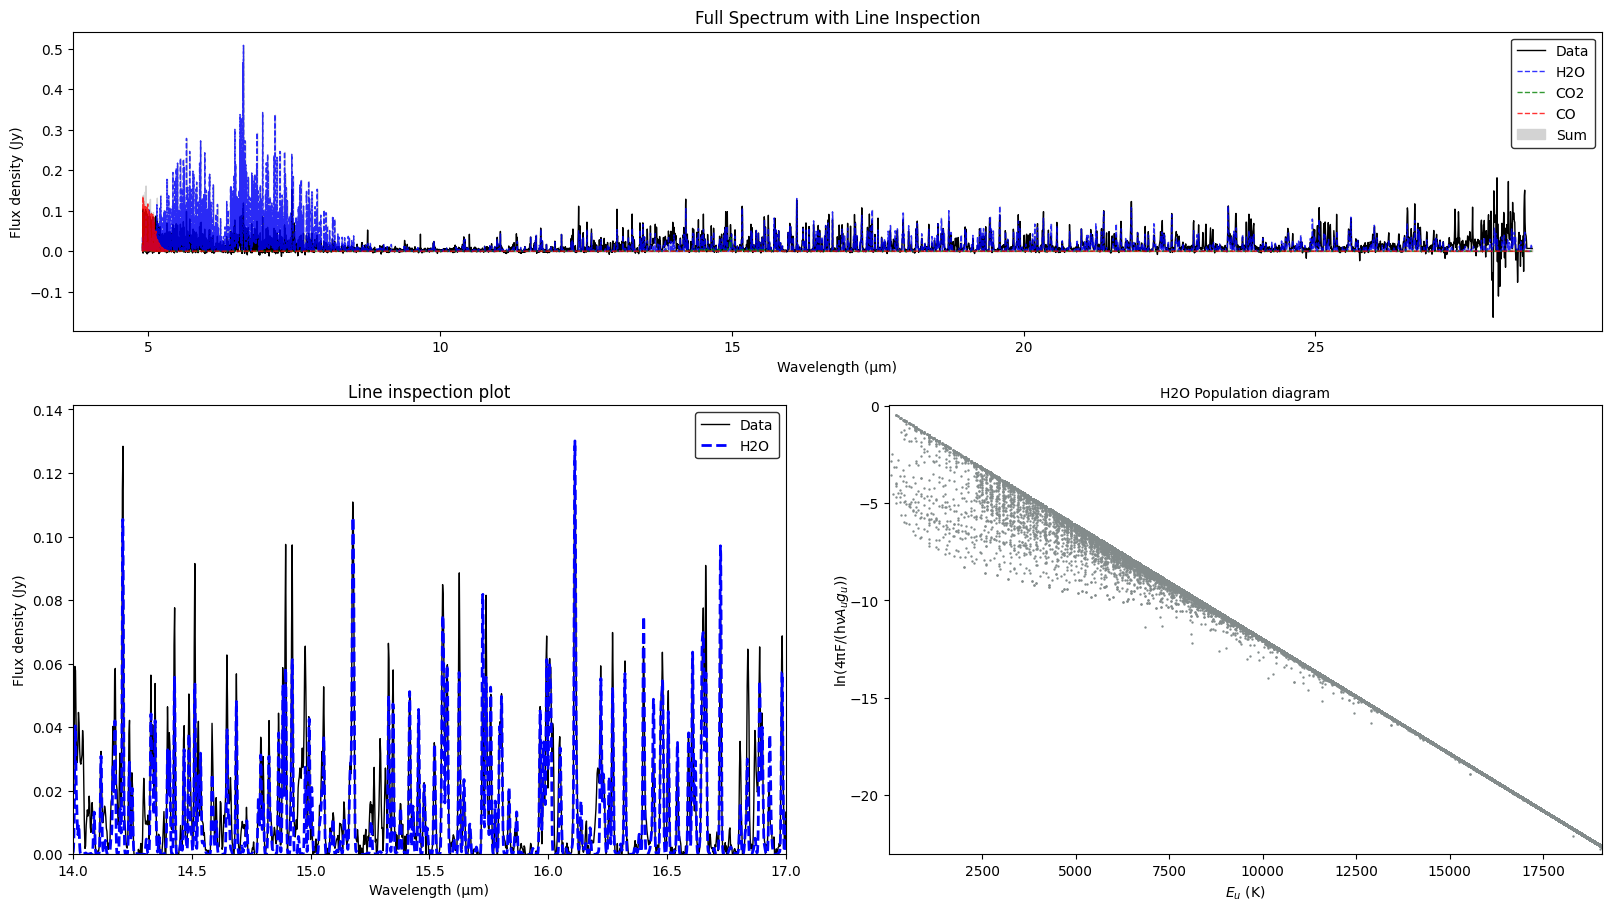

In [12]:
# --- MainPlotGrid with progressive updates ---

grid = MainPlotGrid(
    wave_data=wave_grid,
    flux_data=observed_flux,
    molecules=mol_dict,
    active_molecule=mol_dict["H2O"],
    inspection_range=(14.0, 17.0),
    figsize=(16, 9),
)
grid.generate_plot()
grid.show()

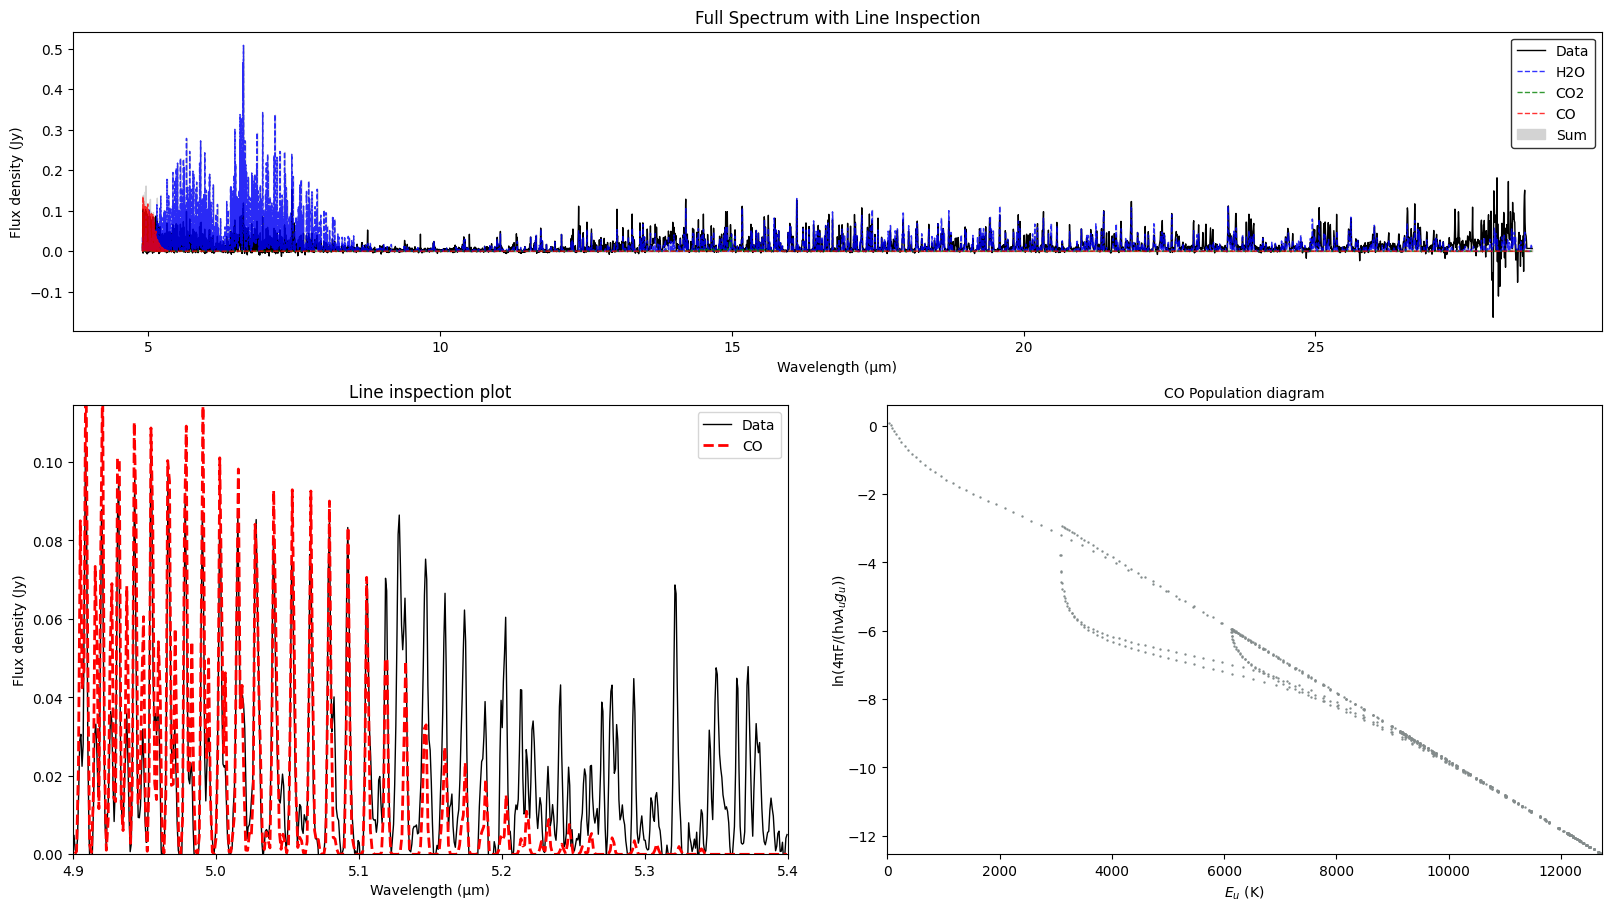

In [13]:
# --- Update 1: switch to CO and a different wavelength range ---

grid.set_active_molecule(mol_dict["CO"])
grid.set_inspection_range(4.9, 5.4)
display(grid.fig)

Found 84 CO lines in 4.9-5.4 um


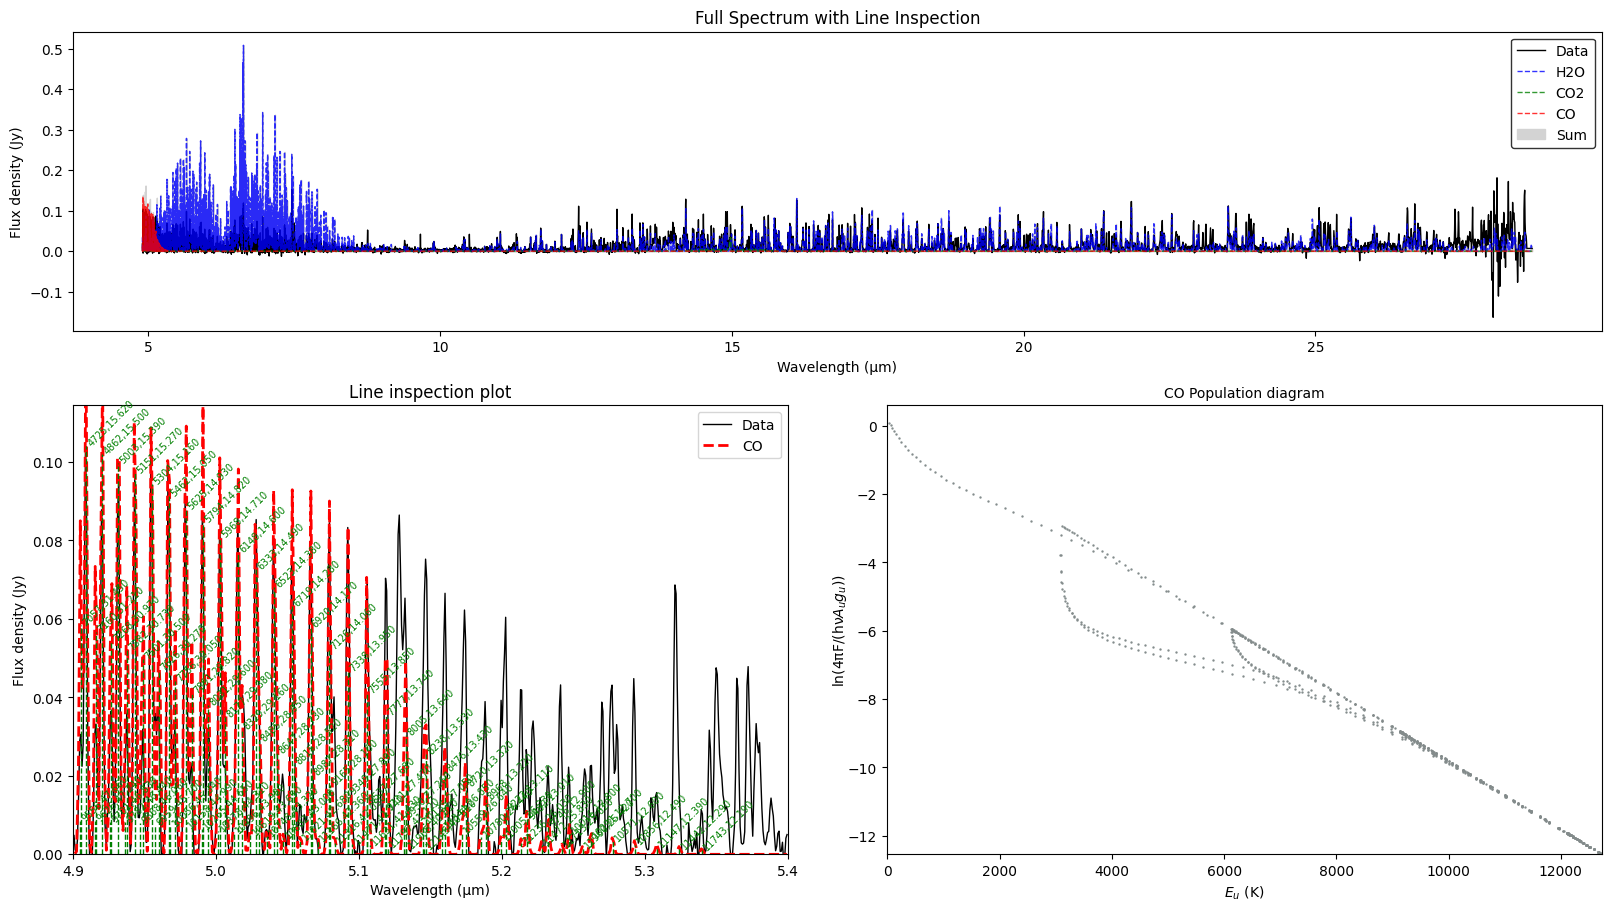

In [14]:
# --- Update 2: add line markers from computed intensity data ---

mol_dict["CO"].calculate_intensity()
co_lines = mol_dict["CO"].intensity.get_lines_in_range_with_intensity(4.9, 5.4)
print(f"Found {len(co_lines)} CO lines in 4.9-5.4 um")

grid.set_line_data(co_lines)
display(grid.fig)

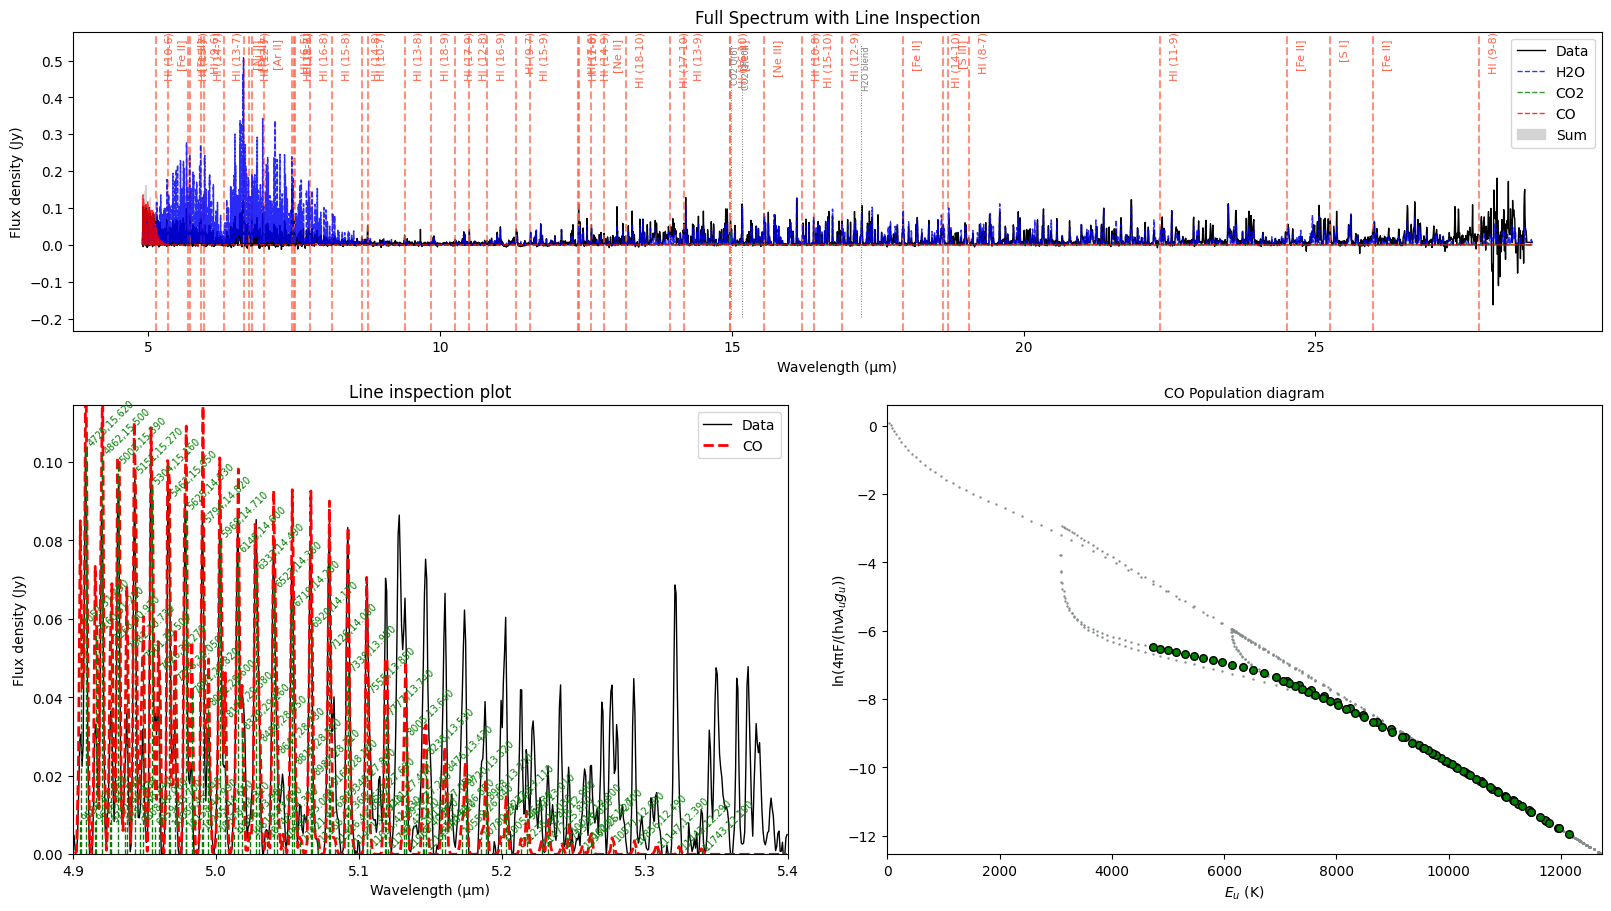

In [15]:
# --- Update 3: add atomic-line & line-list annotations to the top panel ---

grid.atomic_lines = atomic_df
grid.line_list = custom_lines
grid.refresh()    # regenerates all three panels

display(grid.fig)

---
## 6. Multi-Spectrum Comparison

Load two different datasets and plot them side by side using `LineInspectionPlot`
embedded into a custom grid.

Loaded FZTau_MIRI_Pontoppidan+2024.csv: 10672 pts, 4.90-28.72 um


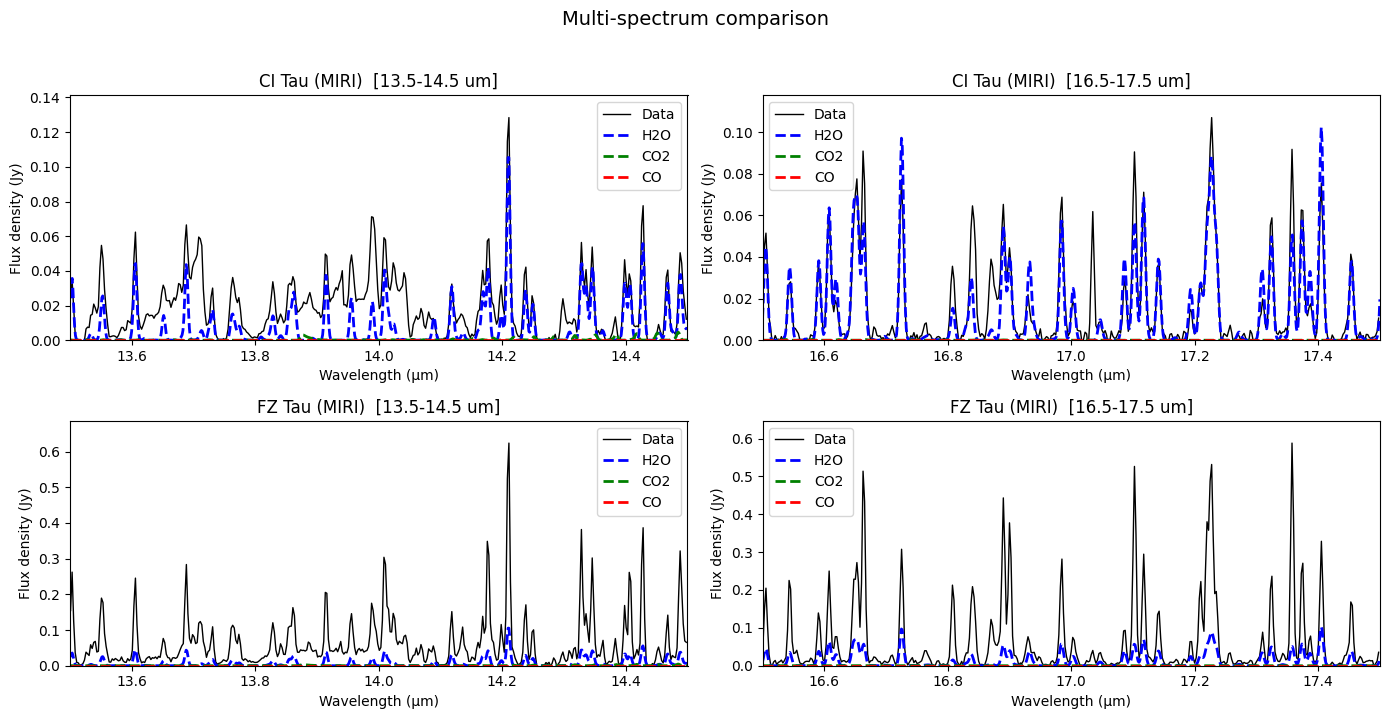

In [16]:
# Load a second spectrum for comparison
data_path_2 = example_data_folder_path / "FZTau_MIRI_Pontoppidan+2024.csv"
obs2 = pd.read_csv(data_path_2)
wave2 = obs2["wave"].values
flux2 = obs2["flux"].values
print(f"Loaded {data_path_2.name}: {len(wave2)} pts, {wave2.min():.2f}-{wave2.max():.2f} um")

# Define two inspection windows
regions = [(13.5, 14.5), (16.5, 17.5)]
datasets = [
    ("CI Tau (MIRI)", wave_grid, observed_flux),
    ("FZ Tau (MIRI)", wave2, flux2),
]

fig, axes = plt.subplots(len(datasets), len(regions),
                         figsize=(7 * len(regions), 3.5 * len(datasets)),
                         squeeze=False)

for row, (label, w, f) in enumerate(datasets):
    for col, (xmin, xmax) in enumerate(regions):
        lip = LineInspectionPlot(
            wave_data=w, flux_data=f,
            xmin=xmin, xmax=xmax,
            molecules=mol_dict,
            ax=axes[row, col],
        )
        lip.generate_plot()
        axes[row, col].set_title(f"{label}  [{xmin}-{xmax} um]")

fig.suptitle("Multi-spectrum comparison", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

---
## 7. Custom Figure Composition

Mix iSLAT plot classes with raw matplotlib in a single `GridSpec` layout.
The key is passing an existing `ax=` to each iSLAT class so it renders onto
your axes instead of creating its own figure.

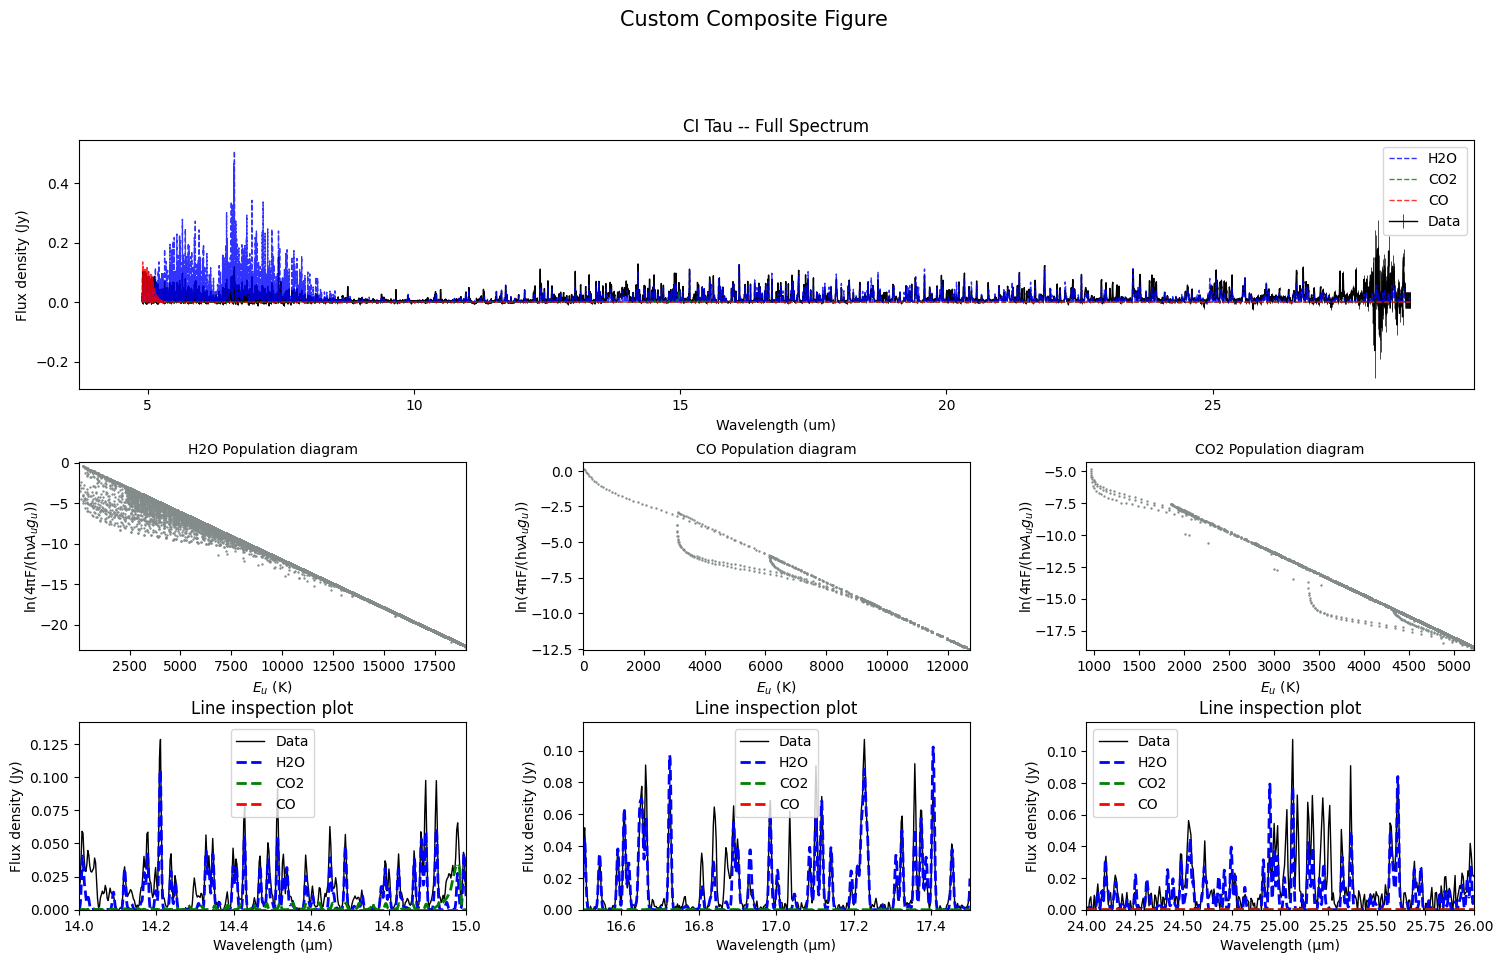

In [17]:
# --- Custom composition: spectrum + 3 molecule pop-diagrams + line inspection ---

fig = plt.figure(figsize=(18, 10))
gs = GridSpec(3, 3, figure=fig, height_ratios=[2, 1.5, 1.5], hspace=0.35, wspace=0.3)

# Row 0: full spectrum spanning all columns
ax_spec = fig.add_subplot(gs[0, :])
helper._plot_observed_spectrum(ax_spec, wave_grid, observed_flux, observed_err)
helper._plot_visible_molecules(ax_spec, mol_dict, wave_data=wave_grid)
ax_spec.set_xlabel("Wavelength (um)")
ax_spec.set_ylabel("Flux density (Jy)")
ax_spec.set_title("CI Tau -- Full Spectrum")

# Row 1: one PopulationDiagramPlot per molecule
for i, mol_name in enumerate(["H2O", "CO", "CO2"]):
    ax_pd = fig.add_subplot(gs[1, i])
    pdp = PopulationDiagramPlot(molecule=mol_dict[mol_name], ax=ax_pd)
    pdp.generate_plot()

# Row 2: three line inspection windows
inspection_windows = [(14.0, 15.0), (16.5, 17.5), (24.0, 26.0)]
for i, (xmin, xmax) in enumerate(inspection_windows):
    ax_li = fig.add_subplot(gs[2, i])
    lip = LineInspectionPlot(
        wave_data=wave_grid, flux_data=observed_flux,
        xmin=xmin, xmax=xmax,
        molecules=mol_dict,
        ax=ax_li,
    )
    lip.generate_plot()

fig.suptitle("Custom Composite Figure", fontsize=15, y=1.01)
plt.show()

---
## 8. Theming All Plot Types

Theming is now **automatic**. Pass a `theme` dictionary at construction time
and `generate_plot()` takes care of backgrounds, text colours, spines, ticks,
and legend styling — no manual per-axes work needed.

### Loading themes

Use `load_theme()` to load any bundled JSON theme by name.  The special name
`"auto"` detects the OS dark/light mode and picks the matching theme:

```python
from iSLAT.Modules.Plotting import load_theme

theme = load_theme("DarkTheme")   # explicit
theme = load_theme("auto")        # auto-detect from OS
```

You can also set `"theme": "auto"` in `UserSettings.json` and the GUI
will follow the system appearance at startup.

In [18]:
# --- Load a dark theme from the bundled JSON files ---
from iSLAT.Modules.Plotting import load_theme

DARK_THEME = load_theme("DarkTheme")
print(f"Loaded theme: {DARK_THEME.get('theme_name', 'unknown')}")

# You can also auto-detect from your OS:
# AUTO_THEME = load_theme("auto")

Loaded theme: Dark Theme


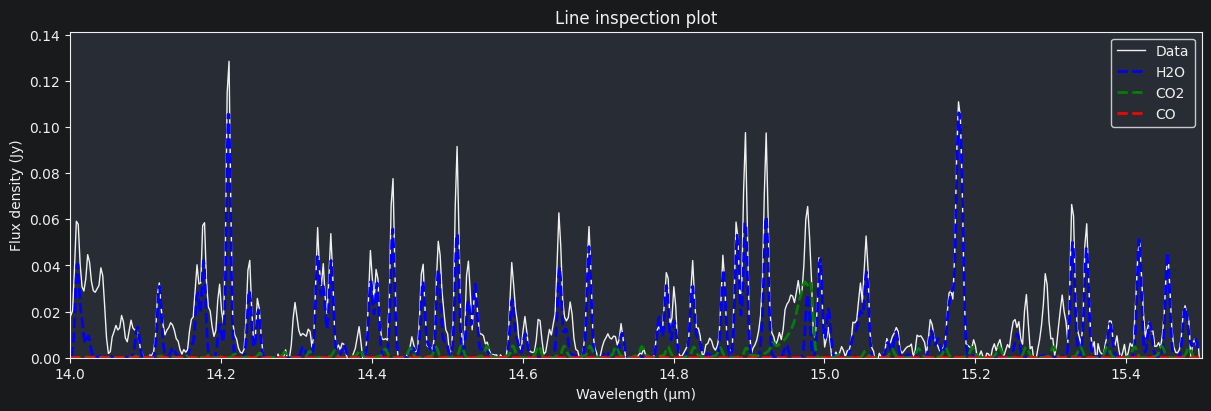

In [ ]:
# --- Dark LineInspectionPlot   ---

lip_dk = LineInspectionPlot(
    wave_data=wave_grid, flux_data=observed_flux,
    xmin=14.0, xmax=15.5,
    molecules=mol_dict,
    theme=DARK_THEME,
    figsize=(12, 4),
)
lip_dk.generate_plot()
lip_dk.show()

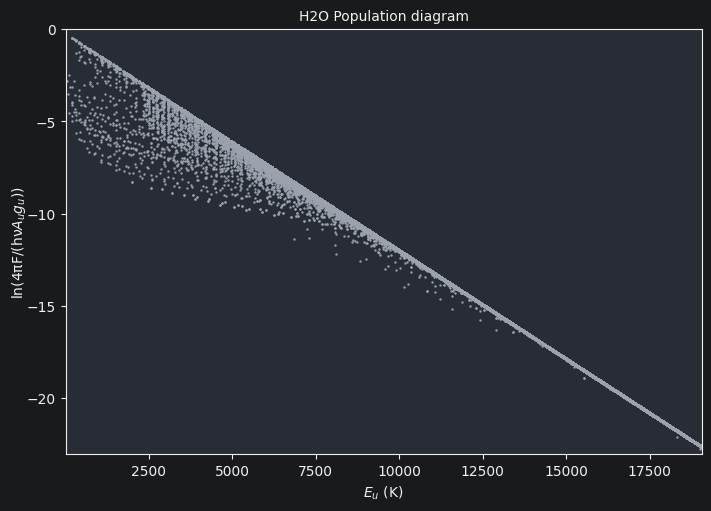

In [ ]:
# --- Dark PopulationDiagramPlot   ---

pdp_dk = PopulationDiagramPlot(
    molecule=mol_dict["H2O"],
    theme=DARK_THEME,
    figsize=(7, 5),
)
pdp_dk.generate_plot()
pdp_dk.show()

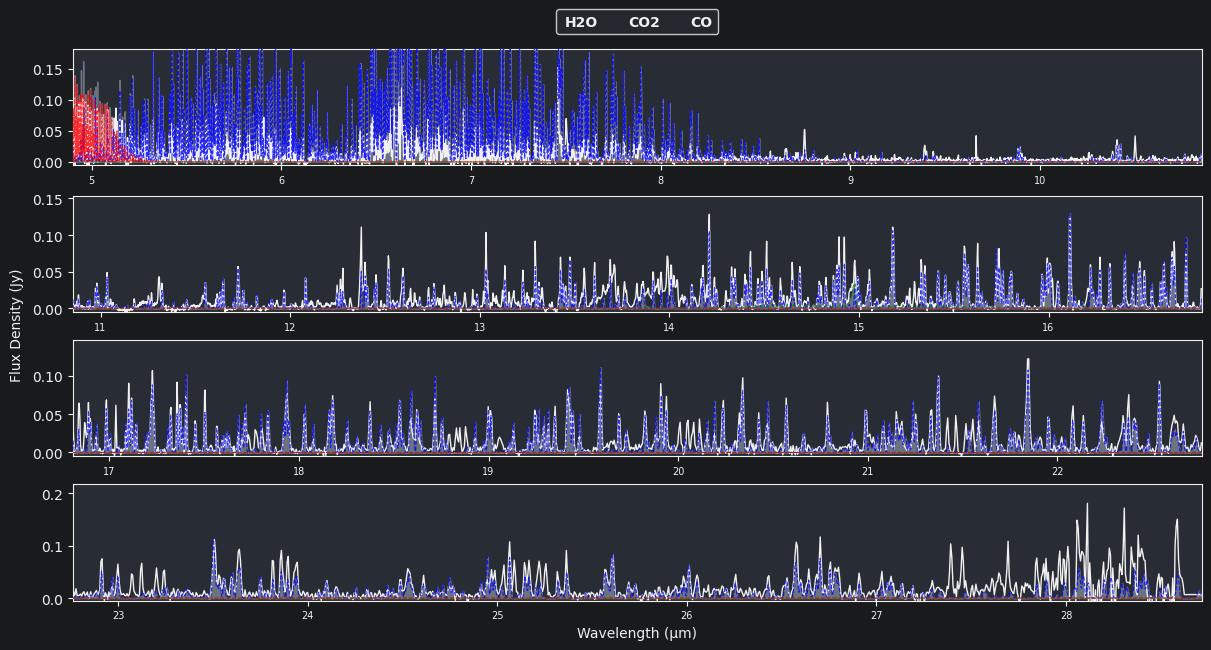

In [ ]:
# --- Dark FullSpectrumPlot   ---

fsp_dk = FullSpectrumPlot(
    wave_data=wave_grid, flux_data=observed_flux,
    molecules=mol_dict,
    n_panels=4,
    theme=DARK_THEME,
)
fsp_dk.generate_plot()
fsp_dk.show()

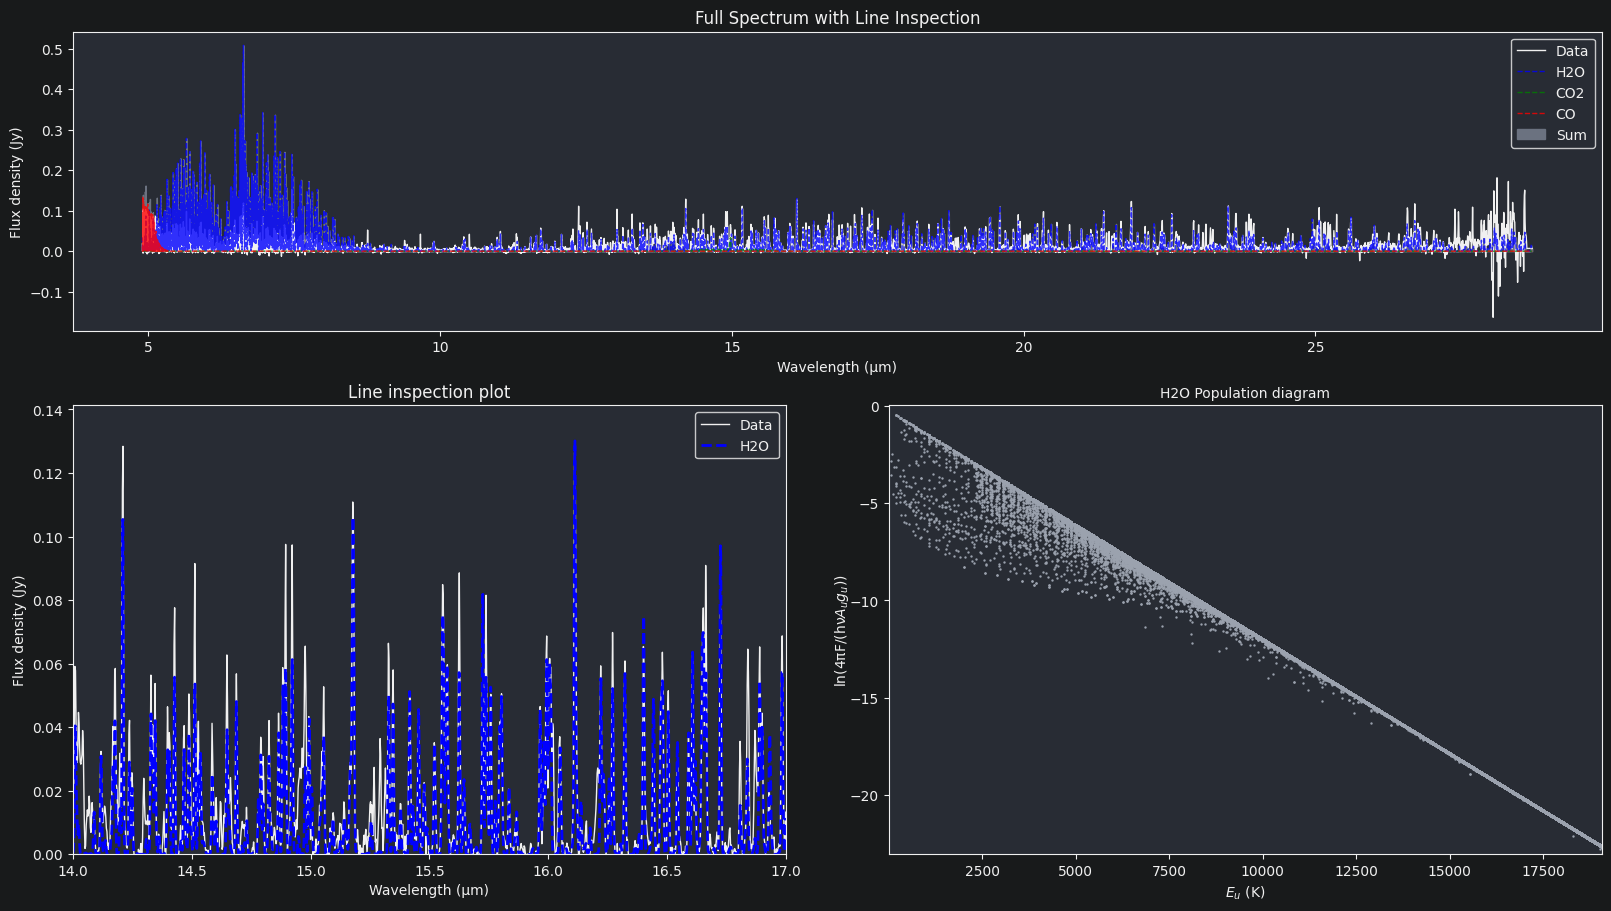

In [ ]:
# --- Dark MainPlotGrid   ---

grid_dk = MainPlotGrid(
    wave_data=wave_grid,
    flux_data=observed_flux,
    molecules=mol_dict,
    active_molecule=mol_dict["H2O"],
    inspection_range=(14.0, 17.0),
    theme=DARK_THEME,
    figsize=(16, 9),
)
grid_dk.generate_plot()
grid_dk.show()

In [ ]:
# --- Save a dark-themed PDF   ---

out_dk = Path.cwd() / "dark_full_spectrum.pdf"
fsp_dk_save = FullSpectrumPlot(
    wave_data=wave_grid, flux_data=observed_flux,
    molecules=mol_dict, n_panels=6, figsize=(12, 14),
    theme=DARK_THEME,
)
fsp_dk_save.generate_plot()

saved = fsp_dk_save.save(out_dk, dpi=150, facecolor=DARK_THEME["background"])
print(f"Saved dark-themed PDF to output directory  ({saved.stat().st_size / 1024:.0f} KB)")
fsp_dk_save.close()

Saved dark-themed PDF to output directory  (487 KB)


---
## Quick Reference

### Plot Classes

| Class | Purpose | Key Constructor Args |
|-------|---------|---------------------|
| `LineInspectionPlot` | Zoomed region | `wave_data`, `flux_data`, `xmin`, `xmax`, `molecule`/`molecules` |
| `PopulationDiagramPlot` | Boltzmann diagram | `molecule`, `highlight_lines` |
| `FullSpectrumPlot` | Multi-panel overview | `wave_data`, `flux_data`, `molecules`, `n_panels`/`step`, `line_list`, `atomic_lines` |
| `MainPlotGrid` | 3-panel composite | `wave_data`, `flux_data`, `molecules`, `active_molecule`, `inspection_range` |

### Common API (all classes)

| Method | Description |
|--------|-------------|
| `generate_plot()` | Build / rebuild the plot |
| `show()` | Display in notebook or window |
| `save(path, dpi=...)` | Export PNG / PDF / SVG |
| `close()` | Free figure memory |
| `get_figure()` | Access `matplotlib.Figure` |
| `apply_theme_to_figure()` | Apply theme backgrounds / colours (called automatically by `generate_plot()`) |

### BasePlot Helpers (call on any subclass instance)

| Method | Description |
|--------|-------------|
| `_plot_observed_spectrum(ax, wave, flux, err)` | Observed data |
| `_plot_molecule_spectrum(ax, mol, wave)` | Single molecule model |
| `_plot_visible_molecules(ax, mol_dict, wave)` | All visible models |
| `_plot_summed_spectrum(ax, wave, flux)` | Summed fill |
| `_plot_line_annotations(ax, df, xr, ymin, ymax)` | Line markers |
| `_plot_atomic_lines(ax, df, xr=...)` | Atomic markers |
| `_update_legend(ax)` | Rebuild legend |
| `get_molecule_display_name(mol)` | Display label |
| `get_molecule_color(mol)` | Assigned colour |
| `get_molecule_spectrum_data(mol, wave)` | `(lambda, flux)` arrays |
| `get_intensity_data(mol)` | Intensity DataFrame |

### Theming

Pass `theme={...}` to any plot class constructor.  `generate_plot()` now
automatically applies backgrounds, text colours, spine colours, and legend
styling — no manual per-axes work required.

```python
from iSLAT.Modules.Plotting import load_theme

theme = load_theme("DarkTheme")   # load from bundled JSON
theme = load_theme("auto")        # auto-detect OS light/dark mode

lip = LineInspectionPlot(..., theme=theme)
lip.generate_plot()               # fully themed automatically
lip.show()
```

Set `"theme": "auto"` in `UserSettings.json` and the GUI + all plots will
follow the system appearance at startup.